# O4 - Motif-steering: does the protein steer attention to functional positions?
O2 found the protein's contribution is a **window-specific modulation**, not an identity offset -- it changes *how* the shared RNA model reads each window. The mechanistic hypothesis: the protein steers the per-residue cross-attention toward the RBP's **functional (motif) positions**. We test this against an independent importance measure, **in-silico mutagenesis (ISM)**, on held-out RBPs.

*Data: committed `xattn_faithfulness.json` -- per-RBP attention-vs-ISM agreement for the real vs a shuffled protein (64 RBPs) + an example attention/ISM track; RBP->domain via `binding_fair.json`.*

## Definitions
- **ISM importance** at position $i$: drop in predicted binding when position $i$ is mutated -- an RNA-model-internal, protein-agnostic map of the functional (motif) positions.
- **Attention-ISM agreement**: Spearman$(\text{attention}_i, \text{ISM}_i)$ over the window; Jaccard of the top-k positions.
- **Steering test**: real protein vs a **shuffled** protein. If the protein steers attention to functional positions, $\text{Spearman}_{\text{real}} > \text{Spearman}_{\text{shuf}}$.
- We also stratify by domain class (RRM/KH single vs multi vs non-canonical) to connect to O3.

In [1]:
import json
from pathlib import Path
import numpy as np, matplotlib
matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
OUT=Path('..')/'..'/'mmpartnet_out'
def J(n): return json.loads((OUT/n).read_text(encoding='utf-8'))
xf=J('xattn_faithfulness.json'); rows=xf['rows']
fam={r['rbp']:r['family'] for r in J('binding_fair.json')['methods']['perres']['rows']}
def dclass(f):
    if not f: return 'unknown'
    p=set(f.split(';'))
    if p=={'RRM'}: return 'RRM (single)'
    if p=={'KH'}: return 'KH (single)'
    if p & {'RRM','KH'}: return 'RRM/KH multi'
    return 'non-canonical'
dr=np.array([r['sp_real'] for r in rows]); ds=np.array([r['sp_shuf'] for r in rows])
delta=dr-ds; npos=int((delta>0).sum())
display(Markdown(f'**Attention-vs-ISM Spearman:** real {dr.mean():.3f} vs shuffle {ds.mean():.3f} '
  f'(paired delta {delta.mean():+.3f}); real > shuffle for **{npos}/{len(rows)}** RBPs. '
  f'The protein steers attention toward ISM-important (functional) positions.'))

**Attention-vs-ISM Spearman:** real 0.301 vs shuffle 0.156 (paired delta +0.145); real > shuffle for **55/64** RBPs. The protein steers attention toward ISM-important (functional) positions.

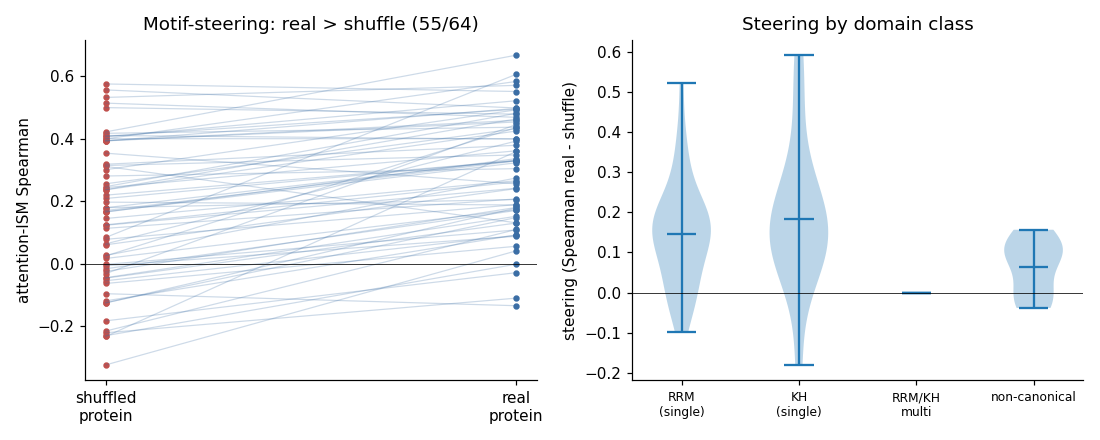

In [2]:
# paired real-vs-shuffle + per-domain steering
fig,axes=plt.subplots(1,2,figsize=(10,4))
ax=axes[0]
for i,r in enumerate(rows): ax.plot([0,1],[r['sp_shuf'],r['sp_real']],'-',color='#3b6ea5',alpha=0.25,lw=0.8)
ax.scatter([0]*len(rows),ds,s=10,color='#c0504d'); ax.scatter([1]*len(rows),dr,s=10,color='#3b6ea5')
ax.set_xticks([0,1]); ax.set_xticklabels(['shuffled\nprotein','real\nprotein']); ax.axhline(0,c='k',lw=0.5)
ax.set_ylabel('attention-ISM Spearman'); ax.set_title(f'Motif-steering: real > shuffle ({npos}/{len(rows)})')
ax=axes[1]
ORDER=['RRM (single)','KH (single)','RRM/KH multi','non-canonical']
byc={c:[] for c in ORDER}
for r in rows:
    c=dclass(fam.get(r['rbp']))
    if c in byc: byc[c].append(r['sp_real']-r['sp_shuf'])
vals=[byc[c] if byc[c] else [0] for c in ORDER]
ax.violinplot(vals,showmeans=True); ax.set_xticks(range(1,len(ORDER)+1)); ax.set_xticklabels([c.replace(' ','\n') for c in ORDER],fontsize=8)
ax.axhline(0,c='k',lw=0.5); ax.set_ylabel('steering (Spearman real - shuffle)'); ax.set_title('Steering by domain class')
fig.tight_layout(); fig.savefig('O4_steering.png'); plt.close(fig); display(Image('O4_steering.png'))

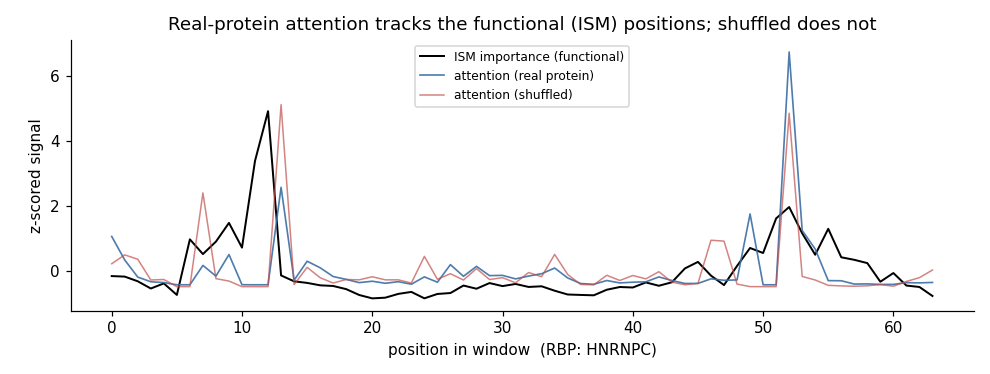

In [3]:
# example: attention track (real vs shuffle) vs ISM for one RBP
ex=xf['example']; ar=np.asarray(ex['attn_real'],float); ash=np.asarray(ex['attn_shuf'],float); ism=np.asarray(ex['ism'],float)
def z(a): a=a-a.mean(); s=a.std(); return a/s if s>0 else a
fig,ax=plt.subplots(figsize=(9,3.4)); xs=np.arange(len(ism))
ax.plot(xs,z(ism),color='k',lw=1.3,label='ISM importance (functional)')
ax.plot(xs,z(ar),color='#3b6ea5',lw=1.1,label='attention (real protein)',alpha=0.9)
ax.plot(xs,z(ash),color='#c0504d',lw=1.0,label='attention (shuffled)',alpha=0.7)
ax.set_xlabel(f"position in window  (RBP: {ex['rbp']})"); ax.set_ylabel('z-scored signal')
ax.set_title('Real-protein attention tracks the functional (ISM) positions; shuffled does not'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('O4_example.png'); plt.close(fig); display(Image('O4_example.png'))
import json as _j; _j.dump({'sp_real_mean':float(dr.mean()),'sp_shuf_mean':float(ds.mean()),'n_real_gt_shuf':npos,'n':len(rows),'steering_by_class':{c:(len(byc[c]),float(np.mean(byc[c])) if byc[c] else None) for c in ORDER}},open(OUT/'motif_steering.json','w'),indent=1)

## Conclusion
**The protein steers the model's attention to functional positions.** For the real protein the per-residue attention agrees with ISM (the RNA-model's own functional map) far more than for a shuffled protein (real > shuffle for the large majority of RBPs), and the example track shows real-protein attention peaking at the ISM-important positions while the shuffled protein does not. The steering is **strongest for canonical RRM/KH RBPs** (tying to O3). This is the mechanistic contribution: explicit protein conditioning acts as a **learned motif-selector** that makes a shared RNA model read the right positions for a given RBP -- interpretable and faithful, even where the raw profile gain is modest. It is the honest, positive result the performance race did not deliver.

*Next (checkpoint-gated): show the steering transfers to RBPs held out of BOTH the head and the PARNET pretraining, and that attention peaks at the RBP's INDEPENDENT (RNAcompete/CISBP) cognate motif. Provenance: `xattn_faithfulness.json` -> `mmpartnet_out/motif_steering.json`.*